In [22]:
import os 
from pathlib import Path
import numpy as np
import glob
import xarray as xr
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import statsmodels.api as sm

os.chdir(Path('/home/globc/garcia/'))

from scenarIA.src.data.dataloader import scenarIA
from scenarIA.src.utils.datautils import dataset_xr_formatting
from scenarIA.src.utils.plotutils import plot_mean_std_simulations, plot_map_image
from scenarIA.src.utils.settings import DATASET_DIR, GRAPHS_DIR, RAW_DATA_DIR
from scenarIA.src.utils.datautils import dataset_xr_formatting, weighted_global_mean

## Outputs : Smooth data with LOWESS

<xarray.Dataset> Size: 24MB
Dimensions:  (member: 1, time: 165, lat: 96, lon: 192)
Coordinates:
  * member   (member) int64 8B 1
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * time     (time) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 2014-01-01
Data variables:
    pr       (member, time, lat, lon) float64 24MB 0.1469 0.1476 ... 0.5071


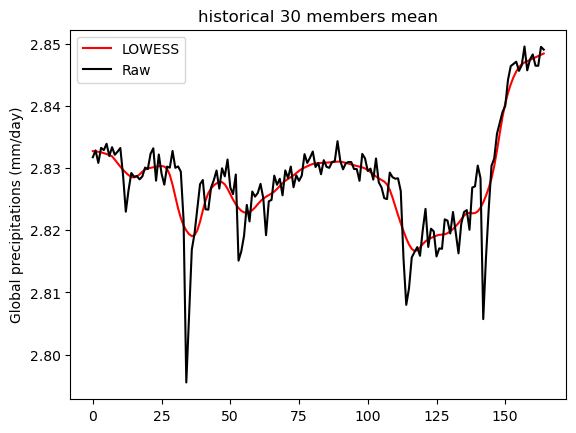

<xarray.Dataset> Size: 24MB
Dimensions:  (member: 1, time: 165, lat: 96, lon: 192)
Coordinates:
  * member   (member) int64 8B 1
  * time     (time) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 2014-01-01
    height   float64 8B ...
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
Data variables:
    pr       (member, time, lat, lon) float64 24MB 0.1469 0.1477 ... 0.4741


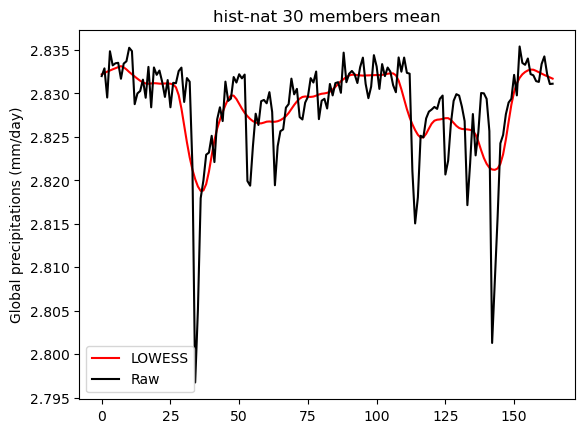

<xarray.Dataset> Size: 24MB
Dimensions:  (member: 1, time: 165, lat: 96, lon: 192)
Coordinates:
  * member   (member) int64 8B 1
  * time     (time) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 2014-01-01
    height   float64 8B ...
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
Data variables:
    pr       (member, time, lat, lon) float64 24MB 0.142 0.1427 ... 0.4692


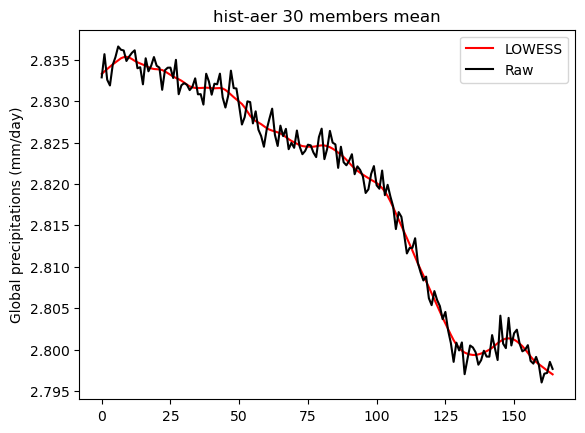

<xarray.Dataset> Size: 24MB
Dimensions:  (member: 1, time: 165, lat: 96, lon: 192)
Coordinates:
  * member   (member) int64 8B 1
  * time     (time) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 2014-01-01
    height   float64 8B ...
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
Data variables:
    pr       (member, time, lat, lon) float64 24MB 0.1462 0.1469 ... 0.523


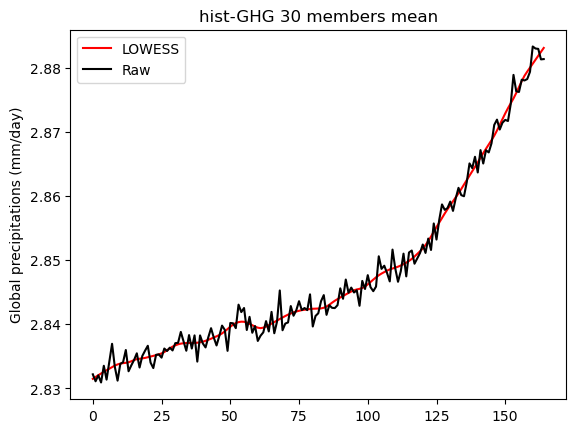

<xarray.Dataset> Size: 13MB
Dimensions:  (member: 1, time: 86, lat: 96, lon: 192)
Coordinates:
  * member   (member) int64 8B 1
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * time     (time) datetime64[ns] 688B 2015-01-01 2016-01-01 ... 2100-01-01
Data variables:
    pr       (member, time, lat, lon) float64 13MB 0.1532 0.1541 ... 0.5318


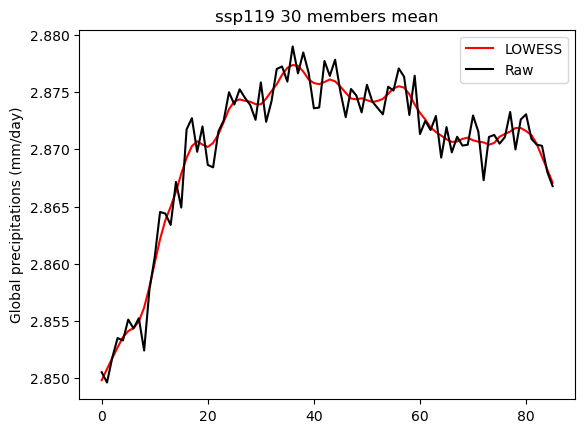

<xarray.Dataset> Size: 13MB
Dimensions:  (member: 1, time: 86, lat: 96, lon: 192)
Coordinates:
  * member   (member) int64 8B 1
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * time     (time) datetime64[ns] 688B 2015-01-01 2016-01-01 ... 2100-01-01
Data variables:
    pr       (member, time, lat, lon) float64 13MB 0.1532 0.1541 ... 0.5239


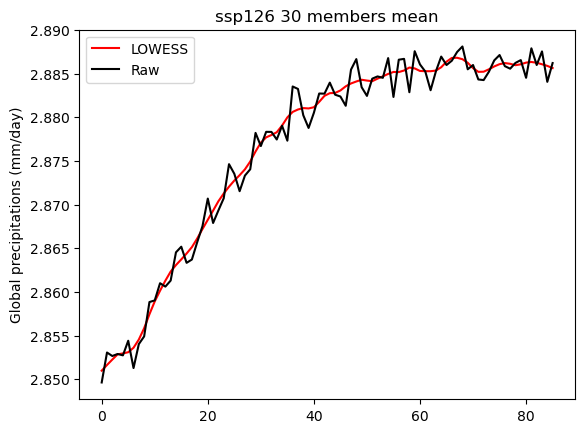

<xarray.Dataset> Size: 13MB
Dimensions:  (member: 1, time: 86, lat: 96, lon: 192)
Coordinates:
  * member   (member) int64 8B 1
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * time     (time) datetime64[ns] 688B 2015-01-01 2016-01-01 ... 2100-01-01
Data variables:
    pr       (member, time, lat, lon) float64 13MB 0.1513 0.152 ... 0.6042


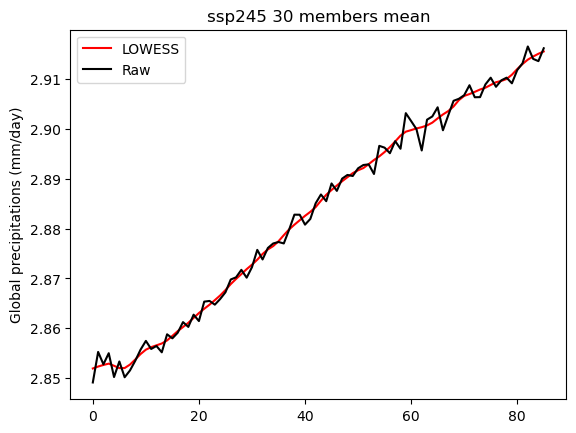

<xarray.Dataset> Size: 13MB
Dimensions:  (member: 1, time: 86, lat: 96, lon: 192)
Coordinates:
  * member   (member) int64 8B 1
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * time     (time) datetime64[ns] 688B 2015-01-01 2016-01-01 ... 2100-01-01
Data variables:
    pr       (member, time, lat, lon) float64 13MB 0.1537 0.1545 ... 0.7198


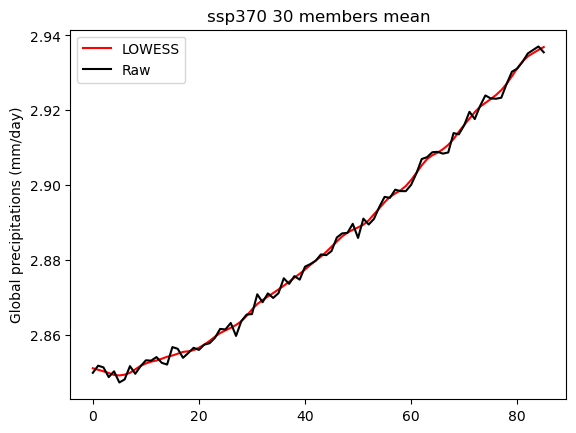

<xarray.Dataset> Size: 13MB
Dimensions:  (member: 1, time: 86, lat: 96, lon: 192)
Coordinates:
  * member   (member) int64 8B 1
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * time     (time) datetime64[ns] 688B 2015-01-01 2016-01-01 ... 2100-01-01
Data variables:
    pr       (member, time, lat, lon) float64 13MB 0.1515 0.1523 ... 0.7875


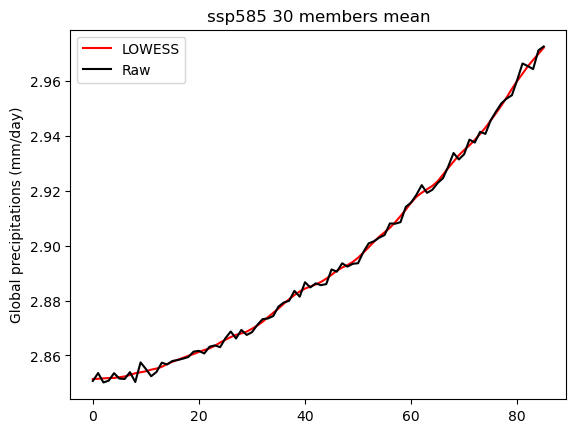

In [21]:
simus = ['historical', 
         'hist-nat', 
         'hist-aer', 
         'hist-GHG', 
         'ssp119', 
         'ssp126', 
         'ssp245', 
         'ssp370', 
         'ssp585']


lowess = sm.nonparametric.lowess
for simu in simus:
    ds = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{simu}.nc')
    ds = scenarIA.get_random_member_subset(ds, seed=42, 
                                     nb_member_per_subsets=30)
    lat = ds.lat.values
    data = ds['pr'].values
    nt, nlat, nlon = data.shape
    data2d = data.reshape(-1, data.shape[1]*data.shape[2])
    
    x = np.arange(0, nt)
    y_lowess = np.empty_like(data2d)
    for i in range(data2d.shape[1]):
        y = data2d[:,i]
        y_lowess[:, i] = lowess(y, x, frac=0.1, it=0, return_sorted=False)
    
    data_lowess = y_lowess.reshape(nt, nlat, nlon)

    ds_lowess = ds.copy().drop_vars(['tas'])
    ds_lowess['pr'].values = data_lowess
    ds_lowess = ds_lowess.expand_dims(dim={'member': [1]}, axis=0)
    ds_lowess.to_netcdf(DATASET_DIR / f'MPI-ESM1-2-LR/annual/outputs_{simu}_lowess0-1.nc')
    print(ds_lowess)
    plt.figure()
    plt.plot(x, weighted_global_mean(data_lowess, lat), label='LOWESS', color='red')
    plt.plot(x, weighted_global_mean(data, lat), label='Raw', color='k')
    plt.legend()
    plt.ylabel('Global precipitations (mm/day)')
    plt.title(f'{simu} 30 members mean')
    plt.show()

## Inputs : create ssp245-aer

In [6]:
ssp245_aer = xr.open_dataset(DATASET_DIR / 'MPI-ESM1-2-LR/annual/inputs_ssp245_regrid2.nc')
for var in ['CO2', 'CH4', 'tau']:
    ssp245_aer[var].values = np.zeros(ssp245_aer['CO2'].values.shape) # time, lat, lon
ssp245_aer = dataset_xr_formatting(ssp245_aer)
ssp245_aer.to_netcdf(DATASET_DIR / 'MPI-ESM1-2-LR/annual/inputs_ssp245-aer_regrid2.nc')
ssp24_aer.close()

## Inputs : create ssp245-aer-ssp370

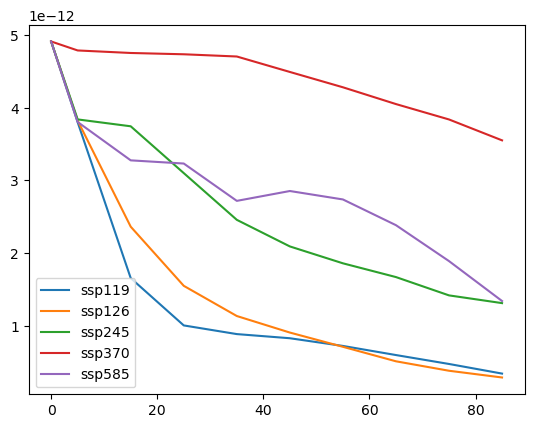

In [34]:
simus = [ 
         'ssp119', 
         'ssp126', 
         'ssp245', 
         'ssp370', 
         'ssp585']
plt.figure()
for simu in simus:
    ds = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/inputs_{simu}_regrid2.nc')
    plt.plot(ds['SO2'].values.mean(axis=(1,2)), label=simu)
plt.legend()
plt.show()

In [49]:
ssp245 = xr.open_dataset(DATASET_DIR / 'MPI-ESM1-2-LR/annual/inputs_ssp245_regrid2.nc')
ssp245_aer_ssp370 = ssp245
ssp370 = xr.open_dataset(DATASET_DIR / 'MPI-ESM1-2-LR/annual/inputs_ssp370_regrid2.nc')['SO2'].values
ssp245_aer_ssp370['SO2'].values = ssp370
ssp245_aer_ssp370['BC'].values = ssp370

ssp245_aer_ssp370.to_netcdf(DATASET_DIR / 'MPI-ESM1-2-LR/annual/inputs_ssp245-aer-ssp370_regrid2.nc')

## Inputs : add volcanic aerosols as new variable

In [2]:
simus = ['historical', 
         'hist-nat', 
         'hist-aer', 
         'hist-GHG', 
         'ssp119', 
         'ssp126', 
         'ssp245', 
         'ssp370', 
         'ssp585']

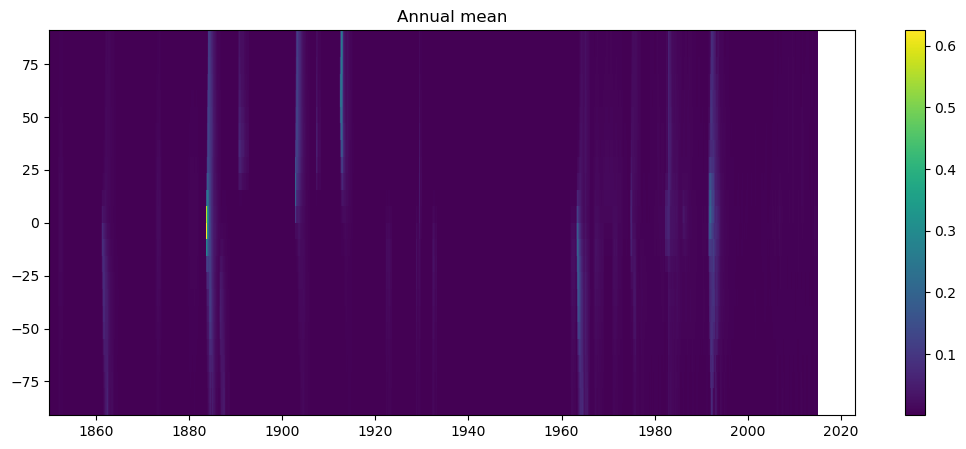

(24,) (96,) (2076, 24)
(2076, 96)


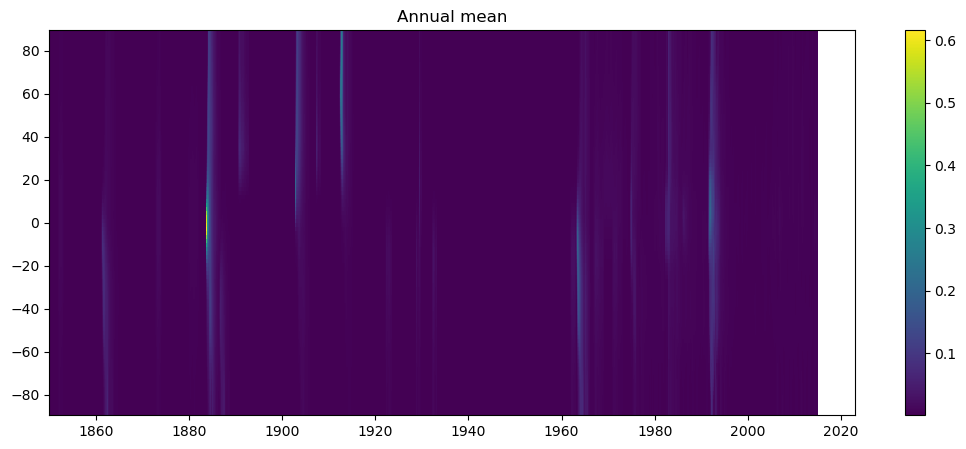

<xarray.Dataset> Size: 2MB
Dimensions:  (month: 2076, lat: 96)
Coordinates:
  * month    (month) datetime64[ns] 17kB 1850-01-15 1850-02-15 ... 2022-12-15
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
Data variables:
    tau      (month, lat) float64 2MB 0.0014 0.0014 0.0014 ... nan nan nan
Attributes: (12/14)
    history:           Reformatted to 24 latitudes, 4 height levels on 2024-0...
    title:             Surface aerea density of stratopheric aerosol,monthly ...
    Institution_id:    IACETH
    Institution:       Institute for Atmosphere and Climate, ETH Zurich, Swit...
    activity_id:       input4CMIPs
    Conventions:       CF-1.1
    ...                ...
    creation_date:     20160519
    source:            SAGE, SAM, CALIPSO, OSIRIS, 2D-model-simulation and Ph...
    source_id:         SAGE CMIP
    further_info_url:  ftp://iacftp.ethz.ch/pub_read/luo/CMIP6/data_descripti...
    contact:           Beiping Luo: beiping.luo@env.ethz.ch or

In [20]:
# Interpolate stratospherical aerosols to MPI grid
file = RAW_DATA_DIR / 'input4mips/tau_reff_CMIP6.v3.nc'
ds = xr.open_dataset(file)
month = ds.month.values
lat_in = ds.lat.values
tau = ds.tau.values

plt.figure(figsize=(13,5))
x, y = np.meshgrid(month, lat_in)
plt.pcolormesh(x, y, tau.transpose(), shading='nearest')
plt.title('Annual mean')
cbar = plt.colorbar()
plt.show()

target_grid_ds = xr.open_dataset(DATASET_DIR / 'MPI-ESM1-2-LR/annual/outputs_hist-nat.nc')
lat_out = target_grid_ds.lat.values

print(lat_in.shape, lat_out.shape, tau.shape)

f = interp1d(lat_in, tau, axis=1,  fill_value='extrapolate')
tau_out = f(lat_out)
print(tau_out.shape)

plt.figure(figsize=(13,5))
x, y = np.meshgrid(month, lat_out)
plt.pcolormesh(x, y, tau_out.transpose(), shading='nearest')
plt.title('Annual mean')
cbar = plt.colorbar()
plt.show()

ds_out = xr.Dataset(
    data_vars=dict(
        tau=(["month", "lat"], tau_out)
    ),
    coords=dict(
        month=("month", month),
        lat=("lat", lat_out)
    ),
    attrs=ds.attrs,
)
print(ds_out)
ds_out.to_netcdf(RAW_DATA_DIR / 'input4mips/tau_reff_CMIP6.v3_regrid.nc')

In [29]:
# create hist-nat file
histnat = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/inputs_hist-aer_regrid2.nc')
histnat['SO2'].values = np.zeros(histnat['SO2'].values.shape)
histnat['BC'].values = np.zeros(histnat['SO2'].values.shape)
histnat.to_netcdf(DATASET_DIR / f'MPI-ESM1-2-LR/annual/inputs_hist-nat_regrid2.nc')

In [43]:
# add stratospherical aerosols to inputs files
file = RAW_DATA_DIR / 'input4mips/tau_reff_CMIP6.v3_regrid.nc'
ds = xr.open_dataset(file).sel(month=slice(None, '2014')).resample(month='YS').mean(dim='month')

for simu in simus:
    input_ds = xr.open_dataset(DATASET_DIR / f'MPI-ESM1-2-LR/annual/inputs_{simu}_regrid2.nc')
    ntime, nlat = input_ds.time.size, input_ds.lat.size
    
    if simu in ['historical', 'hist-nat']:
        input_ds = input_ds.assign({"tau": (
            ("time", "lat"),
            ds.tau.values)})
    else:
        input_ds = input_ds.assign({"tau": (
            ("time", "lat"),
            np.zeros((ntime, nlat)))})
    input_ds.to_netcdf(DATASET_DIR / f'MPI-ESM1-2-LR/annual/inputs_{simu}_regrid.nc')

<xarray.Dataset> Size: 49MB
Dimensions:  (time: 165, lat: 96, lon: 192)
Coordinates:
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * time     (time) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 2014-01-01
Data variables:
    SO2      (time, lat, lon) float64 24MB ...
    BC       (time, lat, lon) float64 24MB ...
    CO2      (time) float64 1kB ...
    CH4      (time) float64 1kB ...
    tau      (time, lat) float64 127kB 0.001408 0.00141 ... 0.003142 0.003142
Attributes:
    regrid_method:  conservative
<xarray.Dataset> Size: 49MB
Dimensions:  (time: 165, lat: 96, lon: 192)
Coordinates:
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * time     (time) datetime64[ns] 1kB 1850-01-01 1851-01-01 ... 2014-01-01
Data variables:
    SO2      (time, lat, lon) float

In [ ]:
## Inputs : Test on land use

<xarray.DataArray 'time' (time: 85)> Size: 680B
array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27.,
       28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41.,
       42., 43., 44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55.,
       56., 57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68., 69.,
       70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81., 82., 83.,
       84.])
Coordinates:
  * time     (time) float64 680B 0.0 1.0 2.0 3.0 4.0 ... 81.0 82.0 83.0 84.0
    height   float64 8B ...
Attributes:
    axis:           T
    bounds:         bounds_time
    calendar:       noleap
    long_name:      time
    realtopology:   linear
    standard_name:  time
    units:          years since 2015-01-01 0:0:0
[3.5253084e-05 1.0736755e-05 1.1463227e-04 ... 2.2042519e-09 1.6413804e-08
 4.1854306e-10]
(85, 96, 192)
(85, 96, 192)


(<Figure size 600x500 with 2 Axes>, <GeoAxes: >)

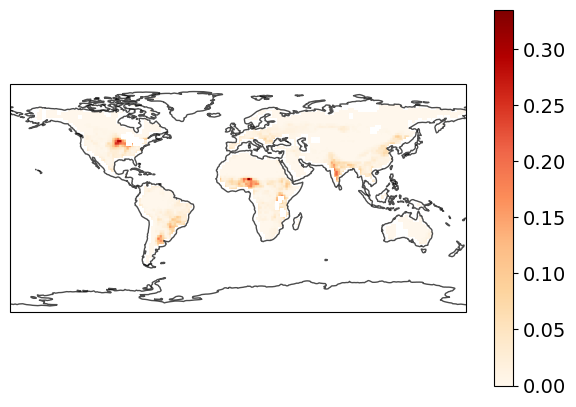

In [9]:
# land use
file = '/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/input4mips/multiple-transitions_input4MIPs_landState_ScenarioMIP_UofMD-IMAGE-ssp126-2-1-f_gn_2015-2100_regrid.nc'
ds = xr.open_dataset(file, decode_times=False)

var_drop = ['primf_harv','primn_harv', 'secmf_harv', 'secyf_harv', 'secnf_harv', 'primf_bioh', 'primn_bioh', 'secmf_bioh', 'secyf_bioh', 'secnf_bioh']
ds = ds.drop_vars(var_drop)

# interpolation ratée ? unité km2/yr
print(ds.time)
data = ds.to_array()

data = np.nansum(np.abs(data), axis=0)
data[data == 0.] = np.nan
print(data[~np.isnan(data)])
print(data.shape)
print(data.shape)
plot_map_image(data[-1])